# Preparação e Carregamento dos Dados
O primeiro passo é importar as ferramentas necessárias e realizar a leitura do dataset já tratado na etapa anterior.

In [3]:
# Importação das bibliotecas 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração do estilo visual do Seaborn para gráficos mais limpos
sns.set_theme(style="whitegrid")

# Leitura do arquivo padronizado
df = pd.read_csv('ecommerce_preparados.csv')

# Exibição inicial para mapear as colunas que serão plotadas
display(df.head())

,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,0,Pijama Cirurgico Scrub Roupa Privativa Hospit...,4.0,273.0,NaN,toronto uniformes profissionais,poliéster,Sem gênero,não definido,"Preço justo , bem feito acabamento ok. Única s...",...,0.629630,0.029969,NaN,0.100645,781,122,1,1000.0,0.002274,0.117326
1,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
2,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
3,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
4,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466


# Gráfico de Histograma
**Objetivo**: Avaliar a distribuição de frequência de uma variável contínua, permitindo entender em qual faixa de preço se concentra a maior parte do estoque.

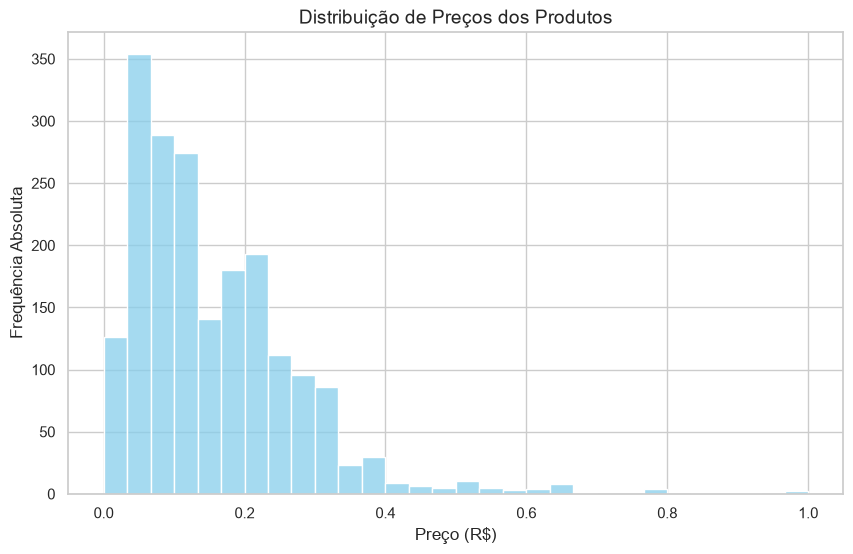

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Preço_MinMax'], bins=30, kde=False, color='skyblue')
plt.title('Distribuição de Preços dos Produtos', fontsize=14)
plt.xlabel('Preço (R$)', fontsize=12)
plt.ylabel('Frequência Absoluta', fontsize=12)
plt.show()

# Gráfico de Dispersão
**Objetivo**: Identificar se existe correlação entre duas variáveis distintas, como o preço do produto e o volume de avaliações que ele recebe.

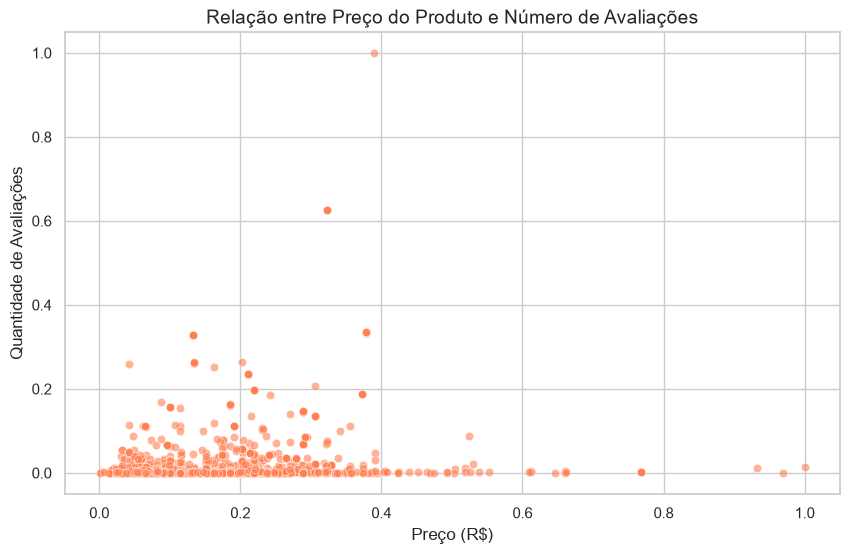

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Preço_MinMax', y='N_Avaliações_MinMax', alpha=0.6, color='coral')
plt.title('Relação entre Preço do Produto e Número de Avaliações', fontsize=14)
plt.xlabel('Preço (R$)', fontsize=12)
plt.ylabel('Quantidade de Avaliações', fontsize=12)
plt.show()

# Mapa de Calor (Heatmap)
**Objetivo**: Destacar a intensidade da correlação linear simultânea entre todas as variáveis numéricas do dataset.

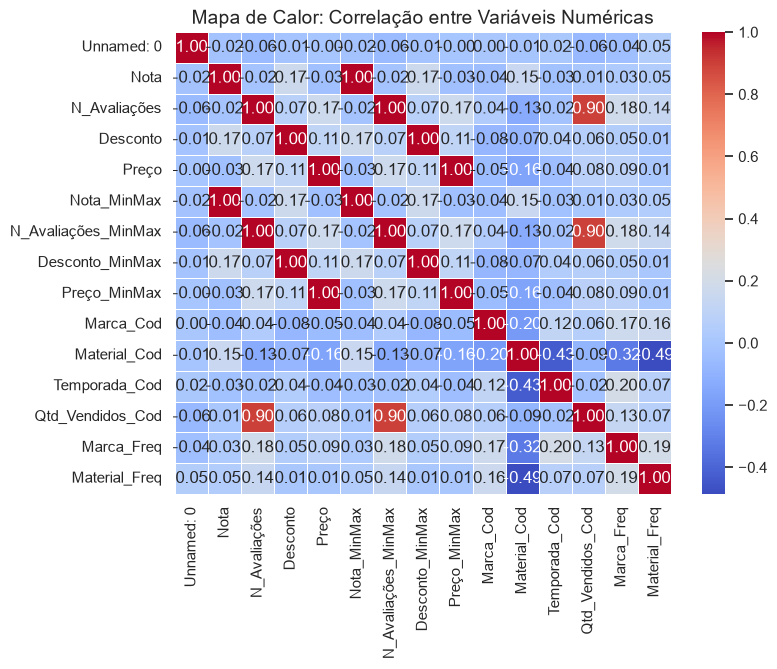

In [8]:
plt.figure(figsize=(8, 6))

# Filtra apenas colunas numéricas para evitar erros no cálculo matemático
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
matriz_correlacao = df[colunas_numericas].corr()

# Criação do mapa de calor com anotações exatas (fmt=".2f")
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Correlação entre Variáveis Numéricas', fontsize=14)
plt.show()

# Gráfico de Barra
**Objetivo**: Comparar o volume de ocorrências entre categorias absolutas, destacando quem domina o portfólio do e-commerce.

C:\Users\Seu Pc\AppData\Local\Temp\ipykernel_11276\89847396.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_marcas.values, y=top_marcas.index, palette='viridis')


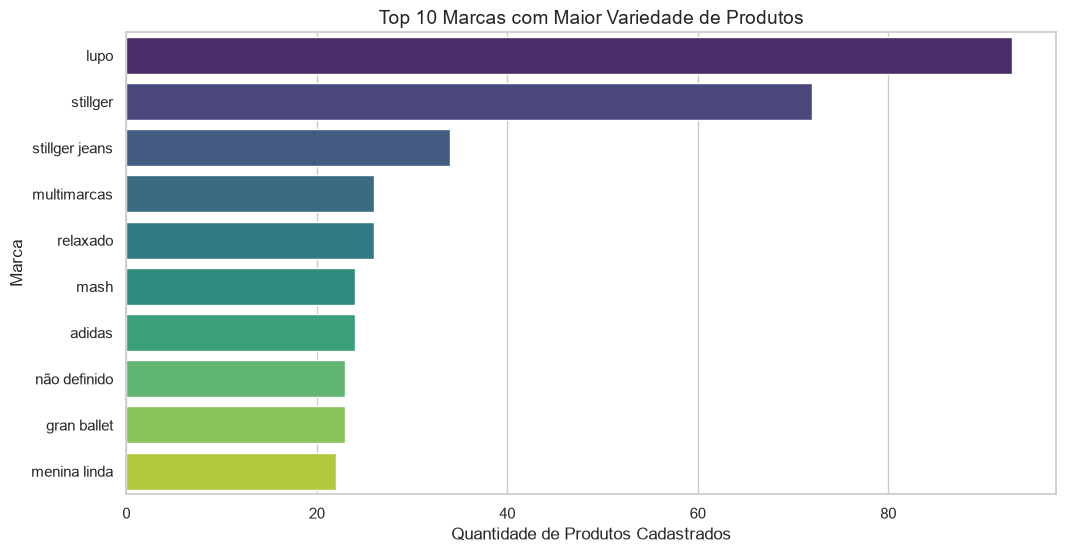

In [9]:
plt.figure(figsize=(12, 6))
# Agrupamento das 10 marcas mais frequentes na base
top_marcas = df['Marca'].value_counts().head(10)

sns.barplot(x=top_marcas.values, y=top_marcas.index, palette='viridis')
plt.title('Top 10 Marcas com Maior Variedade de Produtos', fontsize=14)
plt.xlabel('Quantidade de Produtos Cadastrados', fontsize=12)
plt.ylabel('Marca', fontsize=12)
plt.show()

# Gráfico de Pizza
**Objetivo**: Visualizar a proporção de participação (Market Share) de categorias que possuem poucos valores únicos.

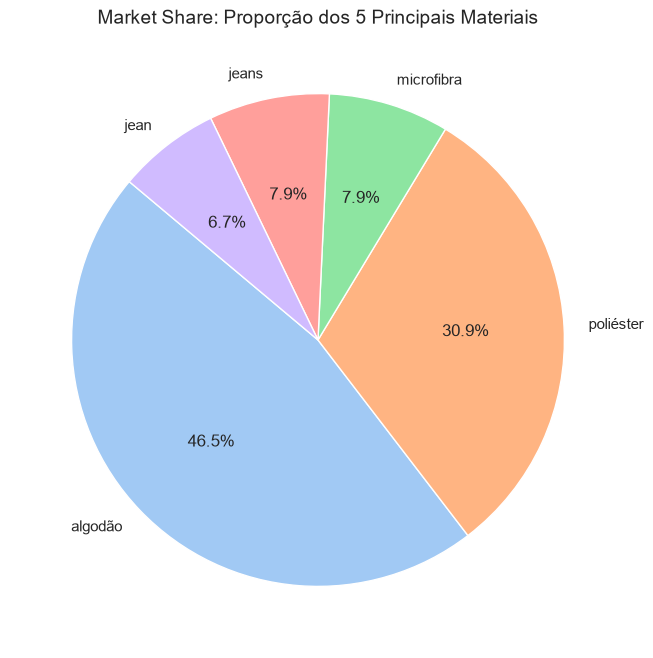

In [10]:
plt.figure(figsize=(8, 8))
# Selecionando as 5 principais categorias de material para o gráfico não ficar poluído
materiais = df['Material'].value_counts().head(5)

plt.pie(materiais.values, labels=materiais.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Market Share: Proporção dos 5 Principais Materiais', fontsize=14)
plt.show()

# Gráfico de Densidade
**Objetivo**: Observar a forma da distribuição dos dados de maneira suavizada, ideal para identificar picos de concentração nas notas dos consumidores.

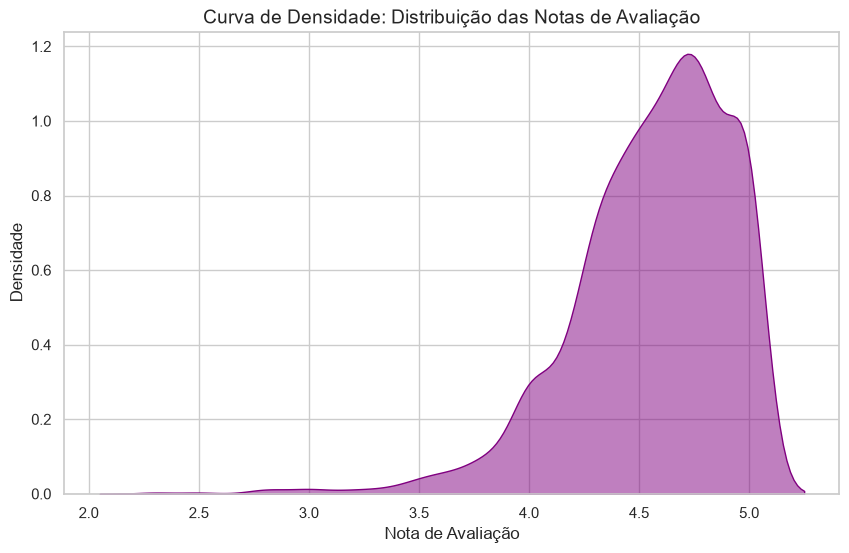

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['Nota'], fill=True, color='purple', alpha=0.5)
plt.title('Curva de Densidade: Distribuição das Notas de Avaliação', fontsize=14)
plt.xlabel('Nota de Avaliação', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.show()

# Gráfico de Regressão
**Objetivo**: Traçar uma linha de tendência algorítmica para observar o impacto direto de uma variável sobre outra (ex: como a porcentagem de desconto reflete na nota do produto).

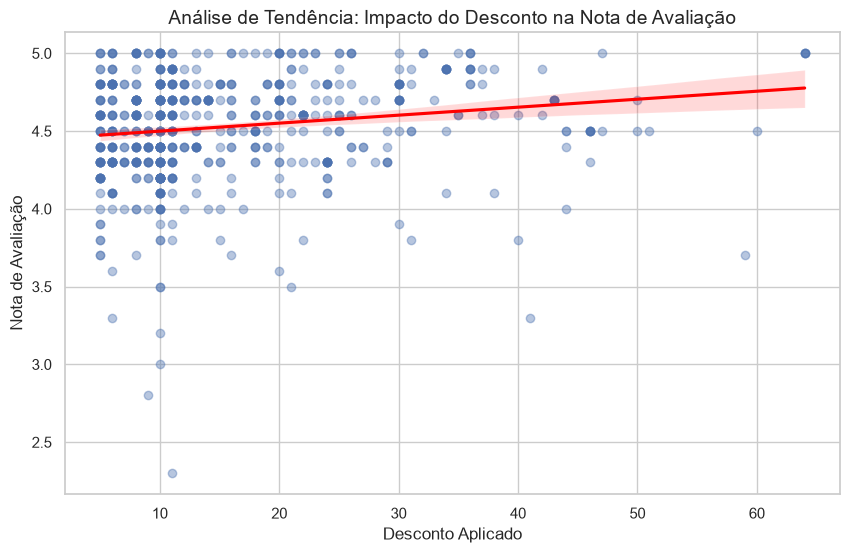

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Desconto', y='Nota', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Análise de Tendência: Impacto do Desconto na Nota de Avaliação', fontsize=14)
plt.xlabel('Desconto Aplicado', fontsize=12)
plt.ylabel('Nota de Avaliação', fontsize=12)
plt.show()